In [1]:
import pandas as pd
import numpy as np
from itertools import chain

# Hi-C utilities imports:
import cooler
import bioframe
import cooltools
from cooltools.lib.numutils import fill_diag
from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorials rely on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# Visualization imports:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches
from matplotlib.ticker import EngFormatter

# helper functions for plotting
bp_formatter = EngFormatter('b')
def format_ticks(ax, x=True, y=True, rotate=True):
    """format ticks with genomic coordinates as human readable"""
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

import datetime
from tqdm.notebook import tqdm

from cooltools.lib.numutils import interp_nan
from matplotlib.colors import LogNorm

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
indir = '../../02-loop_calling_with_chromosight/output'
outdir = '../plots'

In [12]:
test_df = pd.read_csv(f"{indir}/DG_Glut.tsv",sep="\t")

In [13]:
test_df

,chrom1,start1,end1,chrom2,start2,end2,bin1,bin2,kernel_id,iteration,score,pvalue,qvalue
0,chr1,3010000,3020000,chr1,3320000,3330000,301,332,0,0,0.535224,0.000000e+00,0.000000e+00
1,chr1,3010000,3020000,chr1,3450000,3460000,301,345,0,0,0.655913,0.000000e+00,0.000000e+00
2,chr1,3020000,3030000,chr1,3710000,3720000,302,371,0,0,0.730885,0.000000e+00,0.000000e+00
3,chr1,3010000,3020000,chr1,4330000,4340000,301,433,0,0,0.664917,0.000000e+00,0.000000e+00
4,chr1,3030000,3040000,chr1,4740000,4750000,303,474,0,0,0.589706,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
371620,chrX,169360000,169370000,chrX,169400000,169410000,263221,263225,0,0,0.335203,4.938000e-07,5.045000e-07
371621,chrX,169370000,169380000,chrX,169600000,169610000,263222,263245,0,0,0.334469,4.000000e-09,4.600000e-09
371622,chrX,169560000,169570000,chrX,169940000,169950000,263241,263279,0,0,0.422885,3.280000e-08,3.500000e-08
371623,chrX,169600000,169610000,chrX,169740000,169750000,263245,263259,0,0,0.341077,2.300000e-09,2.600000e-09


In [14]:
test_df[test_df['score']>0.85].iloc[100::300]

,chrom1,start1,end1,chrom2,start2,end2,bin1,bin2,kernel_id,iteration,score,pvalue,qvalue
16541,chr1,107230000,107240000,chr1,107480000,107490000,10723,10748,0,0,0.903184,0.0,0.0
56571,chr2,170120000,170130000,chr2,170340000,170350000,36560,36582,0,0,0.866876,0.0,0.0
106531,chr5,34800000,34810000,chr5,34870000,34880000,72895,72902,0,0,0.852744,0.0,0.0
147426,chr7,39850000,39860000,chr7,40270000,40280000,103558,103600,0,0,0.895823,0.0,0.0
185553,chr9,37400000,37410000,chr9,37930000,37940000,130799,130852,0,0,0.883103,0.0,0.0
227138,chr11,56140000,56150000,chr11,57460000,57470000,158203,158335,0,0,0.878228,0.0,0.0
270905,chr14,12580000,12590000,chr14,13920000,13930000,190112,190246,0,0,0.881688,0.0,0.0
320909,chr17,31950000,31960000,chr17,34500000,34510000,224766,225021,0,0,0.879368,0.0,0.0
367404,chrX,134730000,134740000,chrX,134920000,134930000,259758,259777,0,0,0.879590,0.0,0.0


In [15]:
resolution_=10_000
chrom_="chr2"
start_=resolution_*2015
end_=resolution_*2065

In [16]:
temp_df=test_df[(test_df["chrom1"]==chrom_)&(test_df["start1"]>=start_)&(test_df["end2"]<=end_)]
temp_df

,chrom1,start1,end1,chrom2,start2,end2,bin1,bin2,kernel_id,iteration,score,pvalue,qvalue
32881,chr2,20270000,20280000,chr2,20490000,20500000,21575,21597,0,0,0.804745,0.0,0.0


In [ ]:
# indir = ''
clr=cooler.Cooler(f"{indir}/STR_D1_Gaba.Q.10K.mcool::resolutions/10000")

In [18]:
# create a functions that would return a series of rectangles around called dots
# in a specific region, and exposing importnat plotting parameters
def rectangles_around_dots(dots_df, region, loc="upper", lw=1, ec="cyan", fc="none", rec_size=1):
    """
    yield a series of rectangles around called dots in a given region
    """
    # select dots from the region:
    df_reg = bioframe.select(
        bioframe.select(dots_df, region, cols=("chrom1","start1","end1")),
        region,
        cols=("chrom2","start2","end2"),
    )
    rectangle_kwargs = dict(lw=lw, ec=ec, fc=fc)
    # draw rectangular "boxes" around pixels called as dots in the "region":
    for s1, s2, e1, e2 in df_reg[["start1", "start2", "end1", "end2"]].itertuples(index=False):
        width1 = rec_size*(e1 - s1)
        width2 = rec_size*(e2 - s2)
        if loc == "upper":
            yield patches.Rectangle((s2-(rec_size-1)*(e2 - s2)/2, s1-(rec_size-1)*(e1 - s1)/2), width2, width1, **rectangle_kwargs)
        elif loc == "lower":
            yield patches.Rectangle((s1-(rec_size-1)*(e1 - s1)/2, s2-(rec_size-1)*(e2 - s2)/2), width1, width2, **rectangle_kwargs)
        else:
            raise ValueError("loc has to be uppper or lower")

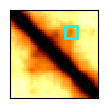

In [19]:
region=(chrom_,start_,end_)


# heatmap kwargs
matshow_kwargs = dict(
    cmap='afmhot_r',
    norm=LogNorm(vmax=0.018, vmin=0.0032),
    extent=(start_, end_, end_, start_)
)

# colorbar kwargs
colorbar_kwargs = dict(fraction=0.046, label='corrected frequencies')

# compute heatmap for the region
region_matrix = clr.matrix(balance=True).fetch((chrom_,start_,end_))
# for diag in [-1,0,1]:
#     region_matrix = fill_diag(region_matrix, np.nan, i=diag)

# see viz.ipynb for details of heatmap visualization
scaling=1
f, ax = plt.subplots(figsize=(scaling*30/25.4, scaling*30/25.4))
im = ax.matshow( region_matrix, **matshow_kwargs)
format_ticks(ax, rotate=False)
ax.set_xticks([])
ax.set_yticks([])
#plt.colorbar(im, ax=ax, **colorbar_kwargs)

# draw rectangular "boxes" around pixels called as dots in the "region":
for box in rectangles_around_dots(temp_df, region, lw=2, rec_size=7):
    ax.add_patch(box)

plt.tight_layout()

plt.savefig(f'{outdir}/01-schematic_for_loop_calling.pdf')
plt.savefig(f'{outdir}/01-schematic_for_loop_calling.png', dpi=600)